### **Step** 1: Install *Dependencies*

In [ ]:
!pip install -q transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### **Step** 2: Load GSM8K Subset*



In [ ]:
from datasets import load_dataset

# Load a subset for faster experiments
gsm8k = load_dataset("gsm8k", "main", split="test[:50]")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.94k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

### Step 2.1: Load SVAMP Dataset

In [ ]:
!git clone https://github.com/arkilpatel/SVAMP.git

import json
from datasets import Dataset

# Load the file from the cloned folder
with open("SVAMP/SVAMP.json", "r") as f:
    raw_data = json.load(f)

# Convert to HuggingFace-style dataset
svamp = Dataset.from_list([
    {"Question": item["Body"], "Answer": str(item["Answer"])}
    for item in raw_data
])


In [ ]:
svamp_subset = svamp.select(range(50))


### **Step** 3: Define Few-Shot CoT Prompt

In [ ]:
# ✍️ Few-shot Chain of Thought prompt examples
few_shot_prefix = """Q: Emily has 3 apples. Her friend gives her 2 more. How many apples does Emily have now?
A: Emily starts with 3 apples. Her friend gives her 2 more. So, 3 + 2 = 5. The answer is 5.

Q: A pen costs 2 dollars. John buys 4 pens. How much does he pay?
A: Each pen costs 2 dollars. John buys 4 pens. So, 2 × 4 = 8. The answer is 8.

Q: Jake read 5 pages on Monday and 7 pages on Tuesday. How many pages did he read in total?
A: Jake read 5 pages on Monday and 7 on Tuesday. So, 5 + 7 = 12. The answer is 12.
"""


### **Step** 4: Define the function used to evaluate the models




In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch
import re

def evaluate_model_fewshot(model_id):
    print(f"Evaluating {model_id} with few-shot CoT...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
    pipe = pipeline("text2text-generation", model=model, tokenizer=tokenizer, max_new_tokens=128)

    correct = 0
    total = 0

    for sample in gsm8k:
        question = sample["question"]
        gt_answer = sample["answer"].split("####")[-1].strip()

        prompt = few_shot_prefix + f"Q: {question}\nA:"
        output = pipe(prompt)[0]["generated_text"]

        match = re.search(r"(\d+(?:\.\d+)?)", output.replace(",", ""))
        if match:
            pred = match.group(1)
            if pred == gt_answer:
                correct += 1
        total += 1

    acc = correct / total
    print(f"Accuracy: {acc:.2%}")
    return acc


### **Step** 5: Run Across Model Sizes and Plot


Evaluating google/flan-t5-small with few-shot CoT...


Device set to use cuda:0


Accuracy: 2.00%
Evaluating google/flan-t5-base with few-shot CoT...


Device set to use cuda:0


Accuracy: 4.00%
Evaluating google/flan-t5-large with few-shot CoT...


Device set to use cuda:0


Accuracy: 4.00%


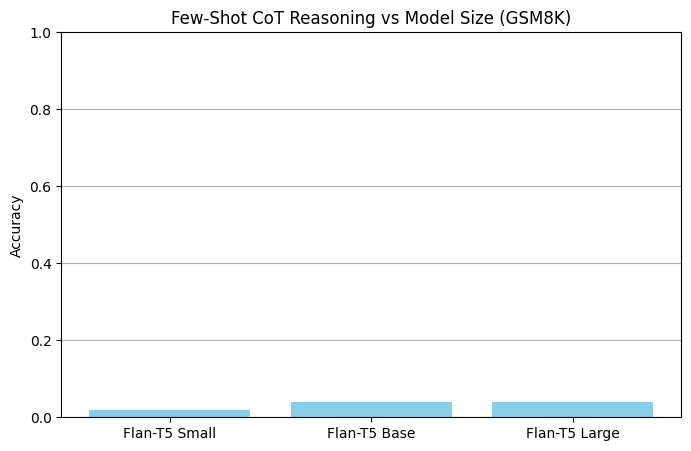

In [ ]:
import matplotlib.pyplot as plt

model_ids = {
    "Flan-T5 Small": "google/flan-t5-small",
    "Flan-T5 Base": "google/flan-t5-base",
    "Flan-T5 Large": "google/flan-t5-large"
}

results = []
for label, model in model_ids.items():
    acc = evaluate_model_fewshot(model)
    results.append((label, acc))

# Plotting
labels = [r[0] for r in results]
scores = [r[1] for r in results]
x = range(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x, scores, color="skyblue")
plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Few-Shot CoT Reasoning vs Model Size (GSM8K)")
plt.ylim(0, 1.0)
plt.grid(True, axis='y')
plt.show()


### Let us check the actual results given by our model

*   List item
*   List item

